In [1]:
# %% ==========================================
# BLOCK 1: SETUP & DEPENDENCIES
# ==========================================
!pip install -q ultralytics

import os
import yaml
import torch
from ultralytics import YOLO
from ultralytics import settings

settings.update({
    "raytune": False
})

# GPU Check
DEVICE = 0 if torch.cuda.is_available() else 'cpu'
print(f"✅ Using execution device: {DEVICE}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.5/46.5 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 49.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 5.2 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
✅ Using execution device: 0


In [2]:
# %% ==========================================
# BLOCK 2: DATASET PATHS & YAML GENERATION
# ==========================================

import os
import yaml

# Actual dataset location
DATASET_ROOT = "/kaggle/input/datasets/nadinpethiyagoda/vehicle-dataset-for-yolo/vehicle dataset"

TRAIN_IMAGES = os.path.join(DATASET_ROOT, "train", "images")
VAL_IMAGES = os.path.join(DATASET_ROOT, "valid", "images")

# Check dataset paths
print("📁 Dataset Root:", DATASET_ROOT)
print("📁 Train Images:", TRAIN_IMAGES)
print("📁 Validation Images:", VAL_IMAGES)

if not os.path.exists(TRAIN_IMAGES):
    raise FileNotFoundError(f"❌ Train images not found: {TRAIN_IMAGES}")

if not os.path.exists(VAL_IMAGES):
    raise FileNotFoundError(f"❌ Validation images not found: {VAL_IMAGES}")

print(f"✅ Train images found: {len(os.listdir(TRAIN_IMAGES))}")
print(f"✅ Validation images found: {len(os.listdir(VAL_IMAGES))}")


# Working directory for generated YAML
WORKING_DIR = "/kaggle/working/vehicle_detection_config"
os.makedirs(WORKING_DIR, exist_ok=True)

YAML_FILE_PATH = os.path.join(WORKING_DIR, "data.yaml")


# 6 vehicle classes
CLASS_NAMES = {
    0: "car",
    1: "threewheel",
    2: "bus",
    3: "truck",
    4: "motorbike",
    5: "van"
}


# YAML configuration
yaml_data = {
    "path": DATASET_ROOT,
    "train": "train/images",
    "val": "valid/images",
    "names": CLASS_NAMES
}


# Create data.yaml
with open(YAML_FILE_PATH, "w") as f:
    yaml.dump(yaml_data, f, default_flow_style=False)


print(f"📄 Generated data.yaml: {YAML_FILE_PATH}")

# Display YAML
print("\n========== data.yaml ==========")
print(open(YAML_FILE_PATH).read())

📁 Dataset Root: /kaggle/input/datasets/nadinpethiyagoda/vehicle-dataset-for-yolo/vehicle dataset
📁 Train Images: /kaggle/input/datasets/nadinpethiyagoda/vehicle-dataset-for-yolo/vehicle dataset/train/images
📁 Validation Images: /kaggle/input/datasets/nadinpethiyagoda/vehicle-dataset-for-yolo/vehicle dataset/valid/images
✅ Train images found: 2100
✅ Validation images found: 900
📄 Generated data.yaml: /kaggle/working/vehicle_detection_config/data.yaml

========== data.yaml ==========
names:
  0: car
  1: threewheel
  2: bus
  3: truck
  4: motorbike
  5: van
path: /kaggle/input/datasets/nadinpethiyagoda/vehicle-dataset-for-yolo/vehicle dataset
train: train/images
val: valid/images



In [3]:
# %% ==========================================
# BLOCK 3: MODEL TRAINING PIPELINE
# ==========================================

model = YOLO("yolov8s.pt")

print("\n🚀 Starting Training Pipeline...")

results = model.train(
    data=YAML_FILE_PATH,
    epochs=30,
    imgsz=640,
    batch=16,
    mosaic=1.0,
    mixup=0.1,
    name="vehicle_detector_v1",
    device=DEVICE
)

print("\n🎉 Model Training Completed Successfully!")
print(f"💾 Best Weights Saved at: {model.trainer.save_dir}/weights/best.pt")


🚀 Starting Training Pipeline...
Ultralytics 8.4.155 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/vehicle_detection_config/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.

In [4]:
# %% ==========================================
# BLOCK 4: INFERENCE / PREDICTION
# ==========================================

best_weights = f"{model.trainer.save_dir}/weights/best.pt"

best_model = YOLO(best_weights)

# Get validation images
val_images = [
    f for f in os.listdir(VAL_IMAGES)
    if f.lower().endswith((".jpg", ".jpeg", ".png", ".webp"))
]

if len(val_images) > 0:

    first_image = os.path.join(VAL_IMAGES, val_images[0])

    print(f"\n🔍 Testing prediction on:")
    print(first_image)

    predictions = best_model.predict(
        source=first_image,
        save=True,
        conf=0.25
    )

    print("\n✅ Prediction completed!")

else:
    print("❌ No validation images found.")


🔍 Testing prediction on:
/kaggle/input/datasets/nadinpethiyagoda/vehicle-dataset-for-yolo/vehicle dataset/valid/images/gettyimages-1174181060-612x612.jpg

image 1/1 /kaggle/input/datasets/nadinpethiyagoda/vehicle-dataset-for-yolo/vehicle dataset/valid/images/gettyimages-1174181060-612x612.jpg: 448x640 1 threewheel, 8.2ms
Speed: 1.6ms preprocess, 8.2ms inference, 1.3ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /kaggle/working/runs/detect/predict

✅ Prediction completed!


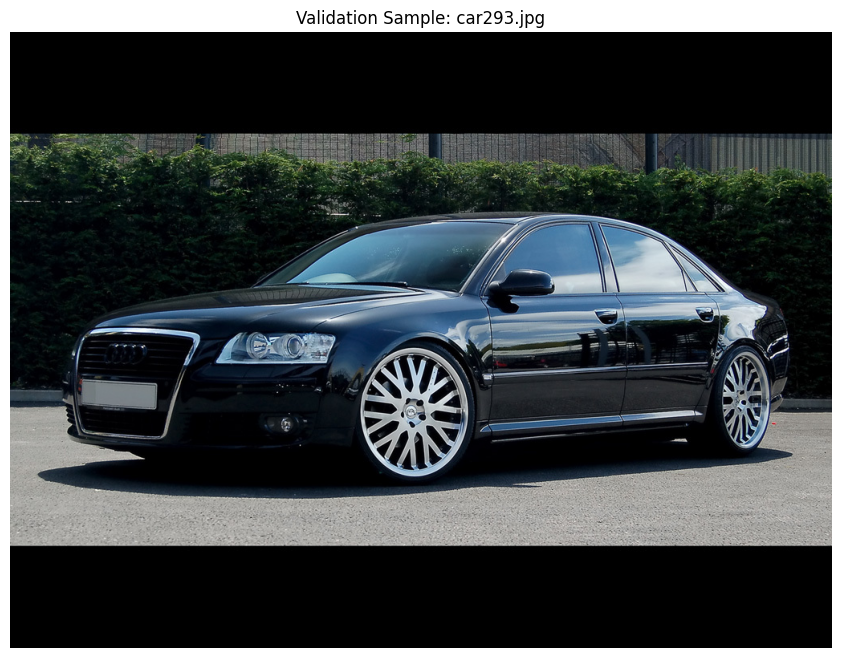

Image: /kaggle/input/datasets/nadinpethiyagoda/vehicle-dataset-for-yolo/vehicle dataset/valid/images/car293.jpg
Labels: /kaggle/input/datasets/nadinpethiyagoda/vehicle-dataset-for-yolo/vehicle dataset/valid/labels/car293.txt
Annotations: 1


In [82]:
# %% ==========================================
# BLOCK 5: DATA VISUALIZATION
# Visualize one validation image and its YOLO annotations
# ==========================================

import random
import matplotlib.pyplot as plt
from PIL import Image

LABELS_DIR = os.path.join(DATASET_ROOT, "valid", "labels")
IMAGE_EXTENSIONS = (".jpg", ".jpeg", ".png", ".webp")

visualization_images = sorted(
    filename for filename in os.listdir(VAL_IMAGES)
    if filename.lower().endswith(IMAGE_EXTENSIONS)
)
if not visualization_images:
    raise FileNotFoundError(f"No validation images found in: {VAL_IMAGES}")

sample_name = random.choice(visualization_images)
sample_image_path = os.path.join(VAL_IMAGES, sample_name)
sample_label_path = os.path.join(
    LABELS_DIR, f"{os.path.splitext(sample_name)[0]}.txt"
)

image = Image.open(sample_image_path).convert("RGB")
label_lines = []
if os.path.exists(sample_label_path):
    with open(sample_label_path, "r") as label_file:
        label_lines = [line.strip() for line in label_file if line.strip()]

plt.figure(figsize=(12, 8))
plt.imshow(image)
plt.axis("off")
plt.title(f"Validation Sample: {sample_name}")
plt.show()

print(f"Image: {sample_image_path}")
print(f"Labels: {sample_label_path}")
print(f"Annotations: {len(label_lines)}")

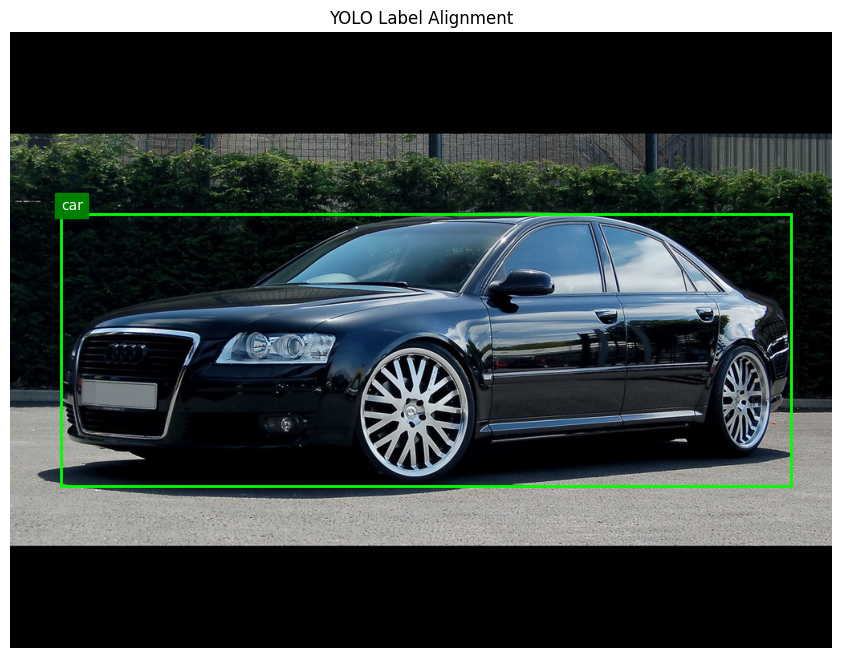

In [83]:
# %% ==========================================
# BLOCK 6: IMAGE PREPROCESSING & LABEL ALIGNMENT
# Convert normalized YOLO labels into pixel coordinates and overlay boxes
# ==========================================

import matplotlib.patches as patches

class_names = [CLASS_NAMES[index] for index in sorted(CLASS_NAMES)]
image_width, image_height = image.size
figure, axis = plt.subplots(figsize=(12, 8))
axis.imshow(image)
axis.axis("off")

for line in label_lines:
    values = line.split()
    if len(values) != 5:
        continue

    class_id, center_x, center_y, box_width, box_height = map(float, values)
    if not 0 <= int(class_id) < len(class_names):
        continue

    pixel_width = box_width * image_width
    pixel_height = box_height * image_height
    left = (center_x * image_width) - (pixel_width / 2)
    top = (center_y * image_height) - (pixel_height / 2)

    axis.add_patch(
        patches.Rectangle(
            (left, top), pixel_width, pixel_height,
            linewidth=2, edgecolor="lime", facecolor="none"
        )
    )
    axis.text(
        left, max(top - 5, 0), class_names[int(class_id)],
        color="white", backgroundcolor="green", fontsize=10
    )

axis.set_title("YOLO Label Alignment")
plt.show()

In [84]:
# %% ==========================================
# BLOCK 7: EVALUATION METRICS
# Evaluate the trained YOLO model on the validation split
# ==========================================

validation_metrics = best_model.val(
    data=YAML_FILE_PATH,
    split="val",
    device=DEVICE,
    plots=False
)

box_metrics = validation_metrics.box
print("Validation metrics:")
print(f"mAP50:     {box_metrics.map50:.4f}")
print(f"mAP50-95:  {box_metrics.map:.4f}")
print(f"Precision: {box_metrics.mp:.4f}")
print(f"Recall:    {box_metrics.mr:.4f}")

Ultralytics 8.4.155 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
Model summary (fused): 72 layers, 11,127,906 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.3±0.6 ms, read: 124.4±127.5 MB/s, size: 57.6 KB)
val: Scanning /kaggle/input/datasets/nadinpethiyagoda/vehicle-dataset-for-yolo/vehicle dataset/valid/labels... 899 images, 0 backgrounds, 1 corrupt: 100% ━━━━━━━━━━━━ 900/900 1.2Kit/s 0.8s0.1ss
val: /kaggle/input/datasets/nadinpethiyagoda/vehicle-dataset-for-yolo/vehicle dataset/valid/images/car55.jpg: ignoring corrupt image/label: [Errno 30] Read-only file system: '/kaggle/input/datasets/nadinpethiyagoda/vehicle-dataset-for-yolo/vehicle dataset/valid/images/car55.jpg'
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/nadinpethiyagoda/vehicle-dataset-for-yolo/vehicle dataset/valid is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 57/57 6.5it/s 8.

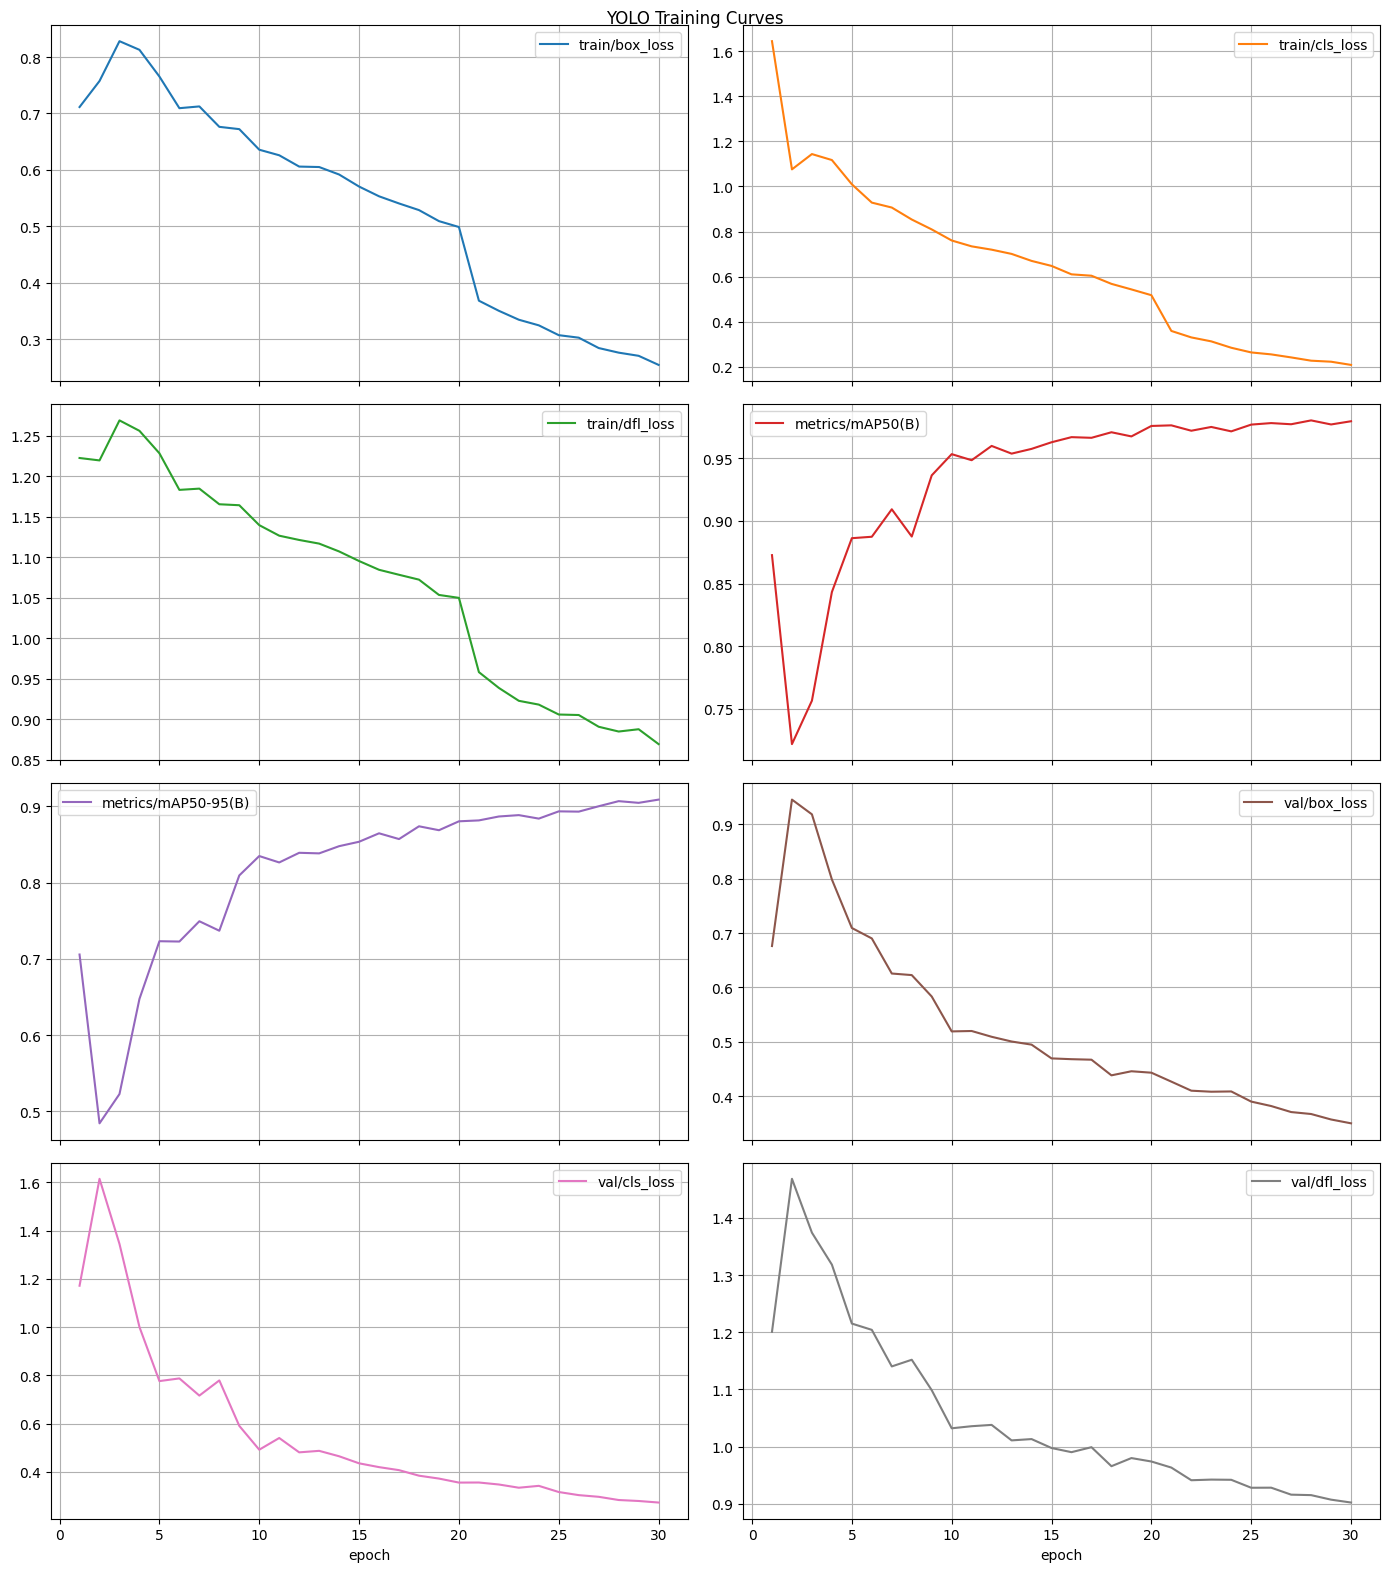

WARNING ⚠️ ConfusionMatrix plot failure: ConfusionMatrix.plot() got an unexpected keyword argument 'names'
Confusion matrix saved in: /kaggle/working/runs/detect/vehicle_detector_v1


In [85]:
# %% ==========================================
# BLOCK 8: TRAINING GRAPHS & CONFUSION MATRIX
# Plot training curves and the YOLO validation confusion matrix
# ==========================================

from pathlib import Path
import math
import pandas as pd

training_results_path = Path(model.trainer.save_dir) / "results.csv"
if training_results_path.exists():
    training_history = pd.read_csv(training_results_path)
    training_history.columns = training_history.columns.str.strip()
    metric_columns = [
        column for column in training_history.columns
        if "loss" in column.lower() or "map" in column.lower()
    ]

    if metric_columns:
        plot_rows = math.ceil(len(metric_columns) / 2)
        training_history.plot(
            x="epoch", y=metric_columns, subplots=True,
            layout=(plot_rows, 2), figsize=(14, 4 * plot_rows),
            title="YOLO Training Curves", grid=True
        )
        plt.tight_layout()
        plt.show()
    else:
        print("No loss or mAP columns found in the training history.")
else:
    print(f"Training history not found: {training_results_path}")

confusion_matrix = validation_metrics.confusion_matrix
confusion_matrix.plot(
    names=class_names,
    normalize=False,
    save_dir=str(model.trainer.save_dir)
)
print(f"Confusion matrix saved in: {model.trainer.save_dir}")

In [86]:
# %% ==========================================
# BLOCK 9: SAVE & EXPORT MODEL
# Export the trained YOLO model for deployment
# ==========================================

exported_model_path = best_model.export(format="onnx", imgsz=640)
print(f"ONNX model exported to: {exported_model_path}")

Ultralytics 8.4.155 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
Model summary (fused): 72 layers, 11,127,906 parameters, 0 gradients, 28.4 GFLOPs

PyTorch: starting from '/kaggle/working/runs/detect/vehicle_detector_v1/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 10, 8400) (21.5 MB)

ONNX: starting export with onnx 1.22.0 opset 18...
ONNX: slimming with onnxslim 0.1.96...
ONNX: export success ✅ 1.6s, saved as '/kaggle/working/runs/detect/vehicle_detector_v1/weights/best.onnx' (42.7 MB)

Export complete (2.2s)
Results saved to /kaggle/working/runs/detect/vehicle_detector_v1/weights/best.onnx
Predict:         yolo predict task=detect model=/kaggle/working/runs/detect/vehicle_detector_v1/weights/best.onnx imgsz=640 
Validate:        yolo val task=detect model=/kaggle/working/runs/detect/vehicle_detector_v1/weights/best.onnx imgsz=640 data=/kaggle/working/vehicle_detection_config/data.yaml  
Visualize:       https://netron.app
ONNX 